In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
import tarfile
import shutil

import face_recognition
import glob
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix
import os
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from face_recognition.face_recognition_cli import image_files_in_folder
import cv2


## Load dataset

In [2]:
# Load images
IMAGES_PATH_TEST = Path("../../../database/face_data/test_data/test_data")
IMAGES_PATH_TRAIN_ME = Path("../../../database/face_data/me")
IMAGES_PATH_TRAIN_NOT_ME = Path("../../../database/face_data/train_data/train_data/it_snotme")

print(f"total test images: {len(image_files_in_folder(IMAGES_PATH_TEST))}")
print(f"total train images (me): {len(image_files_in_folder(IMAGES_PATH_TRAIN_ME))}")
print(f"total train images (not me): {len(image_files_in_folder(IMAGES_PATH_TRAIN_NOT_ME))}")

total test images: 362
total train images (me): 203
total train images (not me): 1585


In [3]:
IMAGES_PATH_ME = Path("../../../database/face_data/train_data/train_data/it_sme")
print(f"total train images (me): {len(image_files_in_folder(IMAGES_PATH_ME))}")

total train images (me): 736


In [4]:
import pandas as pd

# Load dataframes
df = pd.read_csv("../../../database/Dataset.csv.xls")
df

,id,label
0,Robert Downey Jr_87.jpg,Robert Downey Jr
1,Lisa Kudrow_64.jpg,Lisa Kudrow
2,Ellen Degeneres_34.jpg,Ellen Degeneres
3,Billie Eilish_3.jpg,Billie Eilish
4,Hrithik Roshan_35.jpg,Hrithik Roshan
...,...,...
2557,Jessica Alba_90.jpg,Jessica Alba
2558,Elizabeth Olsen_27.jpg,Elizabeth Olsen
2559,Elizabeth Olsen_59.jpg,Elizabeth Olsen
2560,Henry Cavill_7.jpg,Henry Cavill


## Visualize images

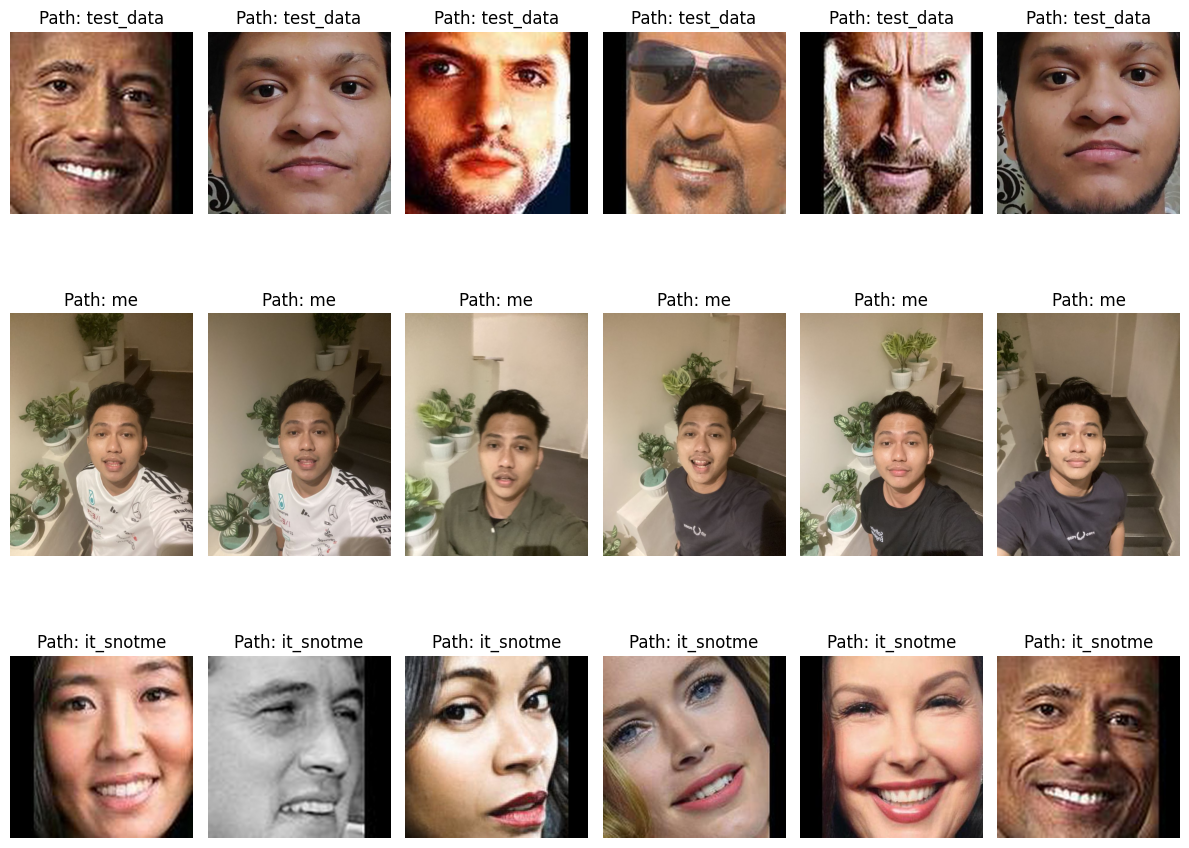

In [5]:
# Load each path images with 6 subplots for each path
fig, axes = plt.subplots(3, 6, figsize=(12, 10))
axes = axes.flatten()
for i, path in enumerate([IMAGES_PATH_TEST, IMAGES_PATH_TRAIN_ME, IMAGES_PATH_TRAIN_NOT_ME]):
    image_files = list(image_files_in_folder(path))
    for j in range(6):
        if j < len(image_files):
            image = face_recognition.load_image_file(image_files[j])
            axes[i*6 + j].imshow(image)
            axes[i*6 + j].set_title(f"Path: {path.name}")
            axes[i*6 + j].axis('off')
plt.tight_layout()
plt.show()


## Similarity search

Encoding test images...


100%|██████████| 362/362 [00:03<00:00, 96.21it/s] 


Encoding train (me) images...


100%|██████████| 203/203 [00:02<00:00, 72.12it/s]


Showing top 5 similar image pair(s).


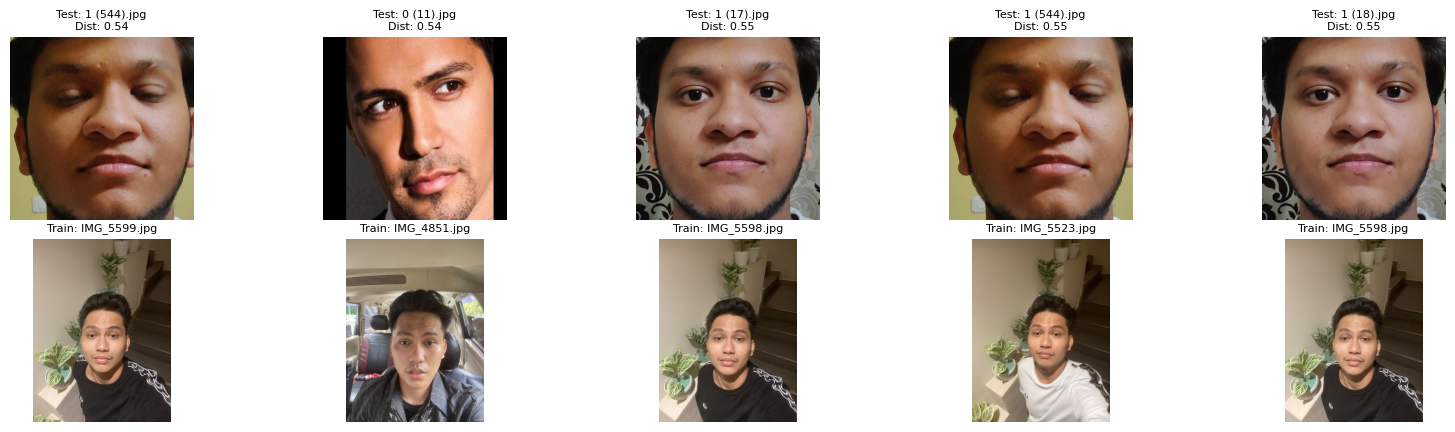

In [6]:

# Find similar images toward (IMAGES_PATH_TEST to IMAGES_PATH_TRAIN_ME)
test_image_files = list(image_files_in_folder(IMAGES_PATH_TEST))
train_me_image_files = list(image_files_in_folder(IMAGES_PATH_TRAIN_ME))

def encode_images(file_list, scale=0.25):
    """Encode face images at reduced scale using HOG (fast) detection."""
    encodings = []
    for f in tqdm(file_list):
        img = face_recognition.load_image_file(f)
        img_small = cv2.resize(img, (0, 0), fx=scale, fy=scale)
        locs = face_recognition.face_locations(img_small, model="hog")
        enc = face_recognition.face_encodings(img_small, known_face_locations=locs, model="small")
        encodings.append((f, enc[0] if enc else None))
    return encodings

print("Encoding test images...")
test_encodings = encode_images(test_image_files)

print("Encoding train (me) images...")
train_encodings = encode_images(train_me_image_files)

# Vectorized comparison: compare each test image against ALL train images at once
train_files = [f for f, enc in train_encodings if enc is not None]
train_encs  = [enc for _, enc in train_encodings if enc is not None]

similar_images = []
for test_image, test_enc in test_encodings:
    if test_enc is None:
        continue
    distances = face_recognition.face_distance(train_encs, test_enc)  # all at once
    for idx, dist in enumerate(distances):
        if dist < 0.6:
            similar_images.append((test_image, train_files[idx], dist))

# Keep only top 5 closest matches to avoid massive plots
similar_images = sorted(similar_images, key=lambda x: x[2])[:5]
print(f"Showing top {len(similar_images)} similar image pair(s).")

if not similar_images:
    print("No similar images found.")
else:
    n = len(similar_images)
    # 2 rows (test on top, train on bottom) x N columns — horizontal layout
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 5), squeeze=False)
    for i, (test_image, train_image, distance) in enumerate(similar_images):
        test_img = face_recognition.load_image_file(test_image)
        train_img = face_recognition.load_image_file(train_image)
        axes[0, i].imshow(test_img)
        axes[0, i].set_title(f"Test: {Path(test_image).name}\nDist: {distance:.2f}", fontsize=8)
        axes[0, i].axis('off')
        axes[1, i].imshow(train_img)
        axes[1, i].set_title(f"Train: {Path(train_image).name}", fontsize=8)
        axes[1, i].axis('off')
    plt.subplots_adjust(wspace=0.05, hspace=0.1)
    plt.show()


In [7]:
# add into dataframe the path of each path images
df["path"] = df["label"].apply(lambda x: IMAGES_PATH_TRAIN_ME if x == "its_me" else IMAGES_PATH_TRAIN_NOT_ME)

## Convert Distances to Similarity Scores

In [8]:
results = []

for test_image, train_image, distance in similar_images:
    
    similarity = (1 - distance) * 100  # Convert distance to similarity percentage
    results.append({
        "test_image": Path(test_image).name,
        "train_image": Path(train_image).name,
        "distance": distance,
        "similarity_percentage": similarity
    })

df_similarity = pd.DataFrame(results)

# Predict Identity (ME vs NOT_ME)
THRESHOLD = 0.6

def classify_face(distance):
    if distance < THRESHOLD:
        return "me"
    
    return "not me"

df_similarity['prediction'] = df_similarity['distance'].apply(classify_face)
df_similarity

,test_image,train_image,distance,similarity_percentage,prediction
0,1 (544).jpg,IMG_5599.jpg,0.541594,45.840569,me
1,0 (11).jpg,IMG_4851.jpg,0.542037,45.796344,me
2,1 (17).jpg,IMG_5598.jpg,0.549661,45.033923,me
3,1 (544).jpg,IMG_5523.jpg,0.551033,44.896700,me
4,1 (18).jpg,IMG_5598.jpg,0.551672,44.832757,me


##  Evaluate Against Ground Truth

In [9]:
df_eval = df_similarity.copy()

# Derive label and path from prediction (no join needed)
df_eval['label'] = df_eval['prediction'].map({'me': 'its_me', 'not me': 'its_not_me'})
df_eval['path'] = df_eval['prediction'].apply(lambda x: str(IMAGES_PATH_TRAIN_ME) if x == 'me' else str(IMAGES_PATH_TRAIN_NOT_ME))
df_eval['id'] = range(len(df_eval))
df_eval

,test_image,train_image,distance,similarity_percentage,prediction,label,path,id
0,1 (544).jpg,IMG_5599.jpg,0.541594,45.840569,me,its_me,../../../database/face_data/me,0
1,0 (11).jpg,IMG_4851.jpg,0.542037,45.796344,me,its_me,../../../database/face_data/me,1
2,1 (17).jpg,IMG_5598.jpg,0.549661,45.033923,me,its_me,../../../database/face_data/me,2
3,1 (544).jpg,IMG_5523.jpg,0.551033,44.896700,me,its_me,../../../database/face_data/me,3
4,1 (18).jpg,IMG_5598.jpg,0.551672,44.832757,me,its_me,../../../database/face_data/me,4


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

report = classification_report(df_eval['label'], df_eval['prediction'])
print(report)

              precision    recall  f1-score   support

      its_me       0.00      0.00      0.00       5.0
          me       0.00      0.00      0.00       0.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



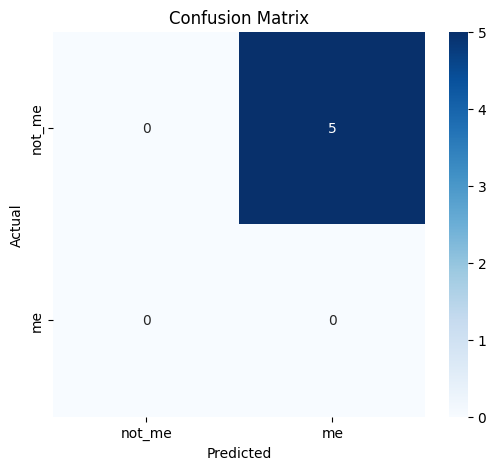

In [11]:
cm = confusion_matrix(df_eval['label'], df_eval['prediction'])
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["not_me","me"],
    yticklabels=["not_me","me"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Distance Distribution Analysis

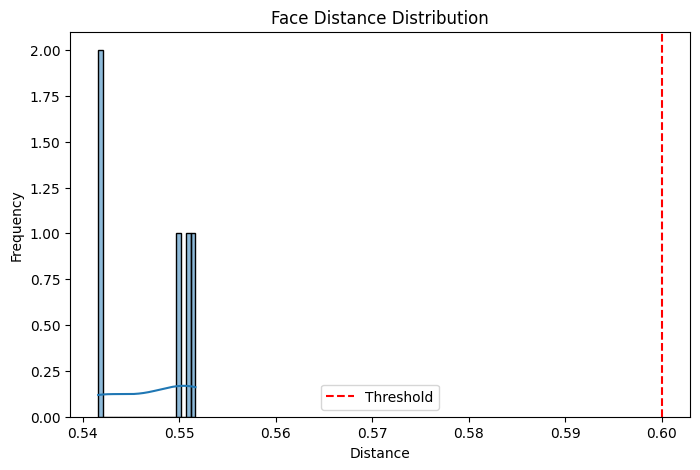

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_similarity["distance"],
    bins=20,
    kde=True
)

plt.axvline(0.6, color="red", linestyle="--", label="Threshold")

plt.title("Face Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.legend()

plt.show()

## Show best matches images

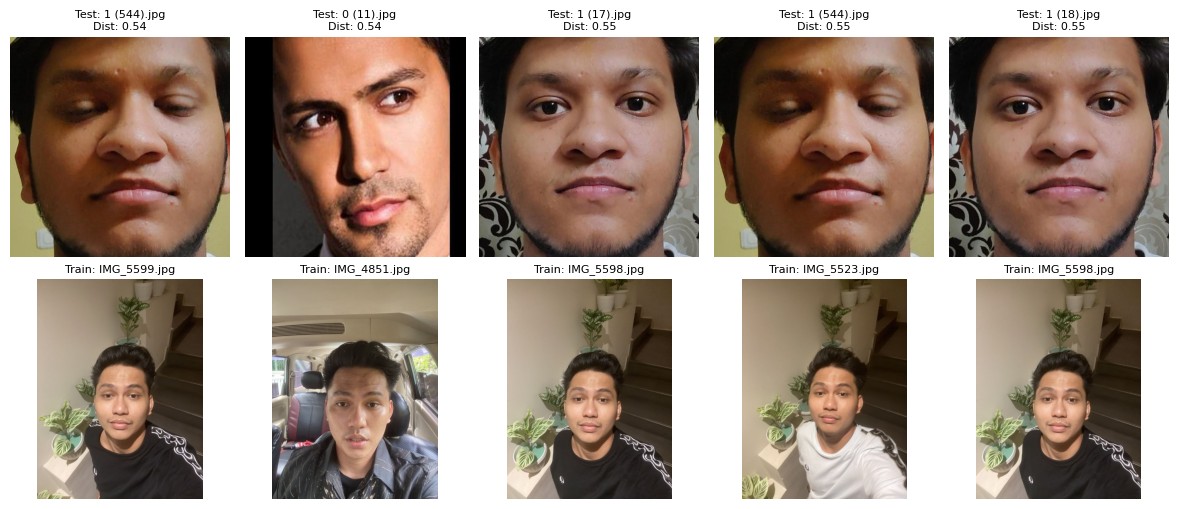

In [13]:
top_matches = df_similarity.sort_values("distance").head(5)

# Create subplots with fig, axes into horizontal layout
fig, axes = plt.subplots(2, 5, figsize=(15, 6), squeeze=False)
for i, (_, row) in enumerate(top_matches.iterrows()):
    test_img = face_recognition.load_image_file(IMAGES_PATH_TEST / row["test_image"])
    train_img = face_recognition.load_image_file(IMAGES_PATH_TRAIN_ME / row["train_image"])

    axes[0, i].imshow(test_img)
    axes[0, i].set_title(f"Test: {row['test_image']}\nDist: {row['distance']:.2f}", fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(train_img)
    axes[1, i].set_title(f"Train: {row['train_image']}", fontsize=8)
    axes[1, i].axis('off')
plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.show()

## 👨‍💻 Goals project

### Detection - Locate faces in photos using Pigo or ONNX SCRFD engines -> Deep learning models chosen
 * #### Detects faces that are partially occluded (covered by hands, objects, etc.)
### Embedding - Generate 512-dimensional vectors to characterize each face using TensorFlow based on FaceNet
* #### Match faces across different photos
* #### Cluster similar faces using the DBSCAN algorithm
* #### Assign faces to people with manual confirmation
### Clustering - Group similar faces using the DBSCAN algorithm so they can be assigned to people